# Spotify Tracks Analysis: Decoding Audio Features and Popularity
---

### Opening Question
**What audio features drive a track's popularity on Spotify? Do energetic and danceable tracks get more popular, or is there a sweet spot that balances musical attributes for mass appeal?**

### Objective
To uncover patterns in the Spotify track dataset by analysing the relationships between audio features [danceability, energy, loudness, acousticness, etc.] and track popularity. Rather than assuming what makes a popular song, I'll examine actual correlations and distributions to identify which features genuinely influence popularity.

### Dataset Overview
- **Sample Size**: 6,000+ tracks from various genres
- **Variables**: track_id, artists, album_name, track_name, popularity, duration_ms, explicit, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, time_signature, track_genre
- **Analysis Approach**: Exploratory Data Analysis [EDA], focusing on feature distributions, genre comparisons, correlations, and a predictive model for popularity using audio features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# set visualisation style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [ ]:
# colour scheme for consistency
primary = "#d59de3"
secondary = "#345882"
success = "#2ca02c"
danger = "#d62728"
warning = "#ff9896"

# gradient for distributions
gradient = ["#d59de3", "#c598dd", "#b592d7", "#a48cd1", "#9386ca", "#8180c2", "#6f7bbb", "#5f74b1", "#526da6", "#46679b", "#3d5f8e", "#345882"]

### 1. What does the dataset look like at first glance?

Let me start with the basics. Load the data, take a look at structure, size, and get an initial sense of what we're working with.

In [3]:
# load the dataset
df = pd.read_csv("spotifytracks.csv")

# drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}")

Dataset shape: (114000, 20)

Column names and types:
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object


In [4]:
# first few rows
print("Sample tracks:")
df.head()

Sample tracks:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# basic statistics for numeric columns
print("\nNumeric summary:")
df.describe()


Numeric summary:


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [6]:
# data quality check
print("\nMissing values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missing_data, "Percent": missing_percent})
print(missing_df[missing_df["Missing"] > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values:
            Missing   Percent
artists           1  0.000877
album_name        1  0.000877
track_name        1  0.000877

Duplicate rows: 450


### 2. Understanding Genre and Key Features

What genres are represented? What are the basic audio feature distributions?

Top 15 genres:
track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
Name: count, dtype: int64

Percentages [top 15]:
track_genre
acoustic         0.88
afrobeat         0.88
alt-rock         0.88
alternative      0.88
ambient          0.88
anime            0.88
black-metal      0.88
bluegrass        0.88
blues            0.88
brazil           0.88
breakbeat        0.88
british          0.88
cantopop         0.88
chicago-house    0.88
children         0.88
Name: count, dtype: float64


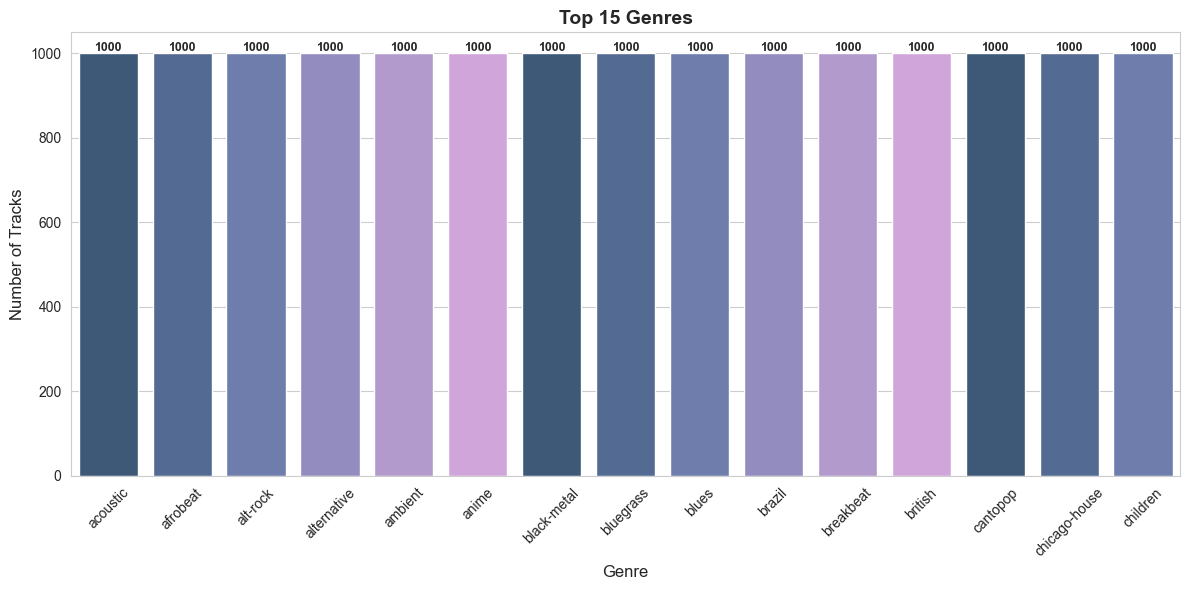

In [7]:
# genre distribution - top 15
genre_counts = df["track_genre"].value_counts()
print("Top 15 genres:")
print(genre_counts.head(15))
print(f"\nPercentages [top 15]:")
print((genre_counts.head(15) / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=genre_counts.head(15).index, y=genre_counts.head(15).values, palette=gradient[::-1], ax=ax)
ax.set_title('Top 15 Genres', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Number of Tracks', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(genre_counts.head(15).values):
    ax.text(i, v + 5, f'{v}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

Popularity statistics:
Mean: 33.24
Median: 35.00
Min: 0.00
Max: 100.00


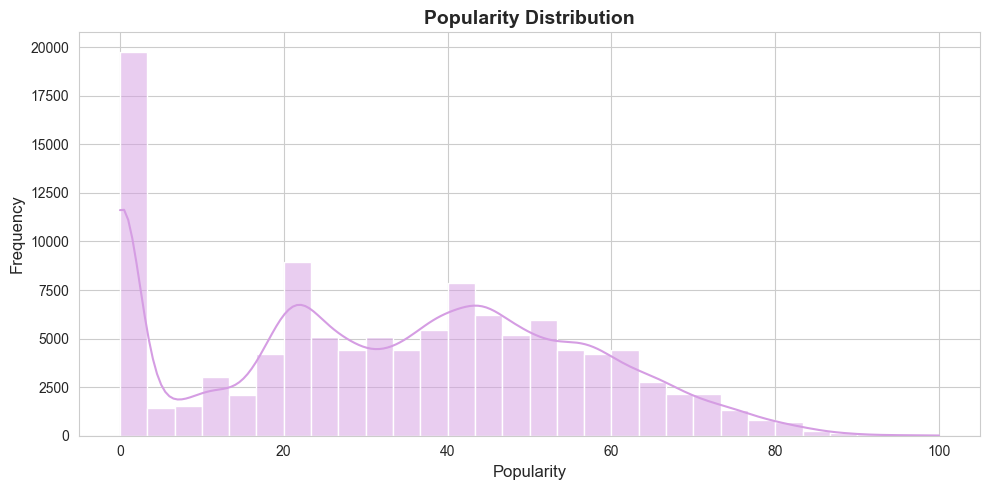

In [8]:
# popularity distribution
print("Popularity statistics:")
print(f"Mean: {df['popularity'].mean():.2f}")
print(f"Median: {df['popularity'].median():.2f}")
print(f"Min: {df['popularity'].min():.2f}")
print(f"Max: {df['popularity'].max():.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['popularity'], bins=30, kde=True, color=primary, ax=ax)
ax.set_title('Popularity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Popularity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# audio feature summary
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
print("Audio feature statistics:")
df[feature_cols].describe()

Audio feature statistics:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,1.140000e+05
mean,0.566800,0.641383,-8.258960,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,2.280292e+05
std,0.173542,0.251529,5.029337,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,1.072977e+05
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.456000,0.472000,-10.013000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,1.740660e+05
50%,0.580000,0.685000,-7.004000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,2.129060e+05
75%,0.695000,0.854000,-5.003000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,2.615060e+05
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.237295e+06


### 3. Audio Feature Distributions

Let's visualise the distributions of key audio features to understand their ranges and typical values.

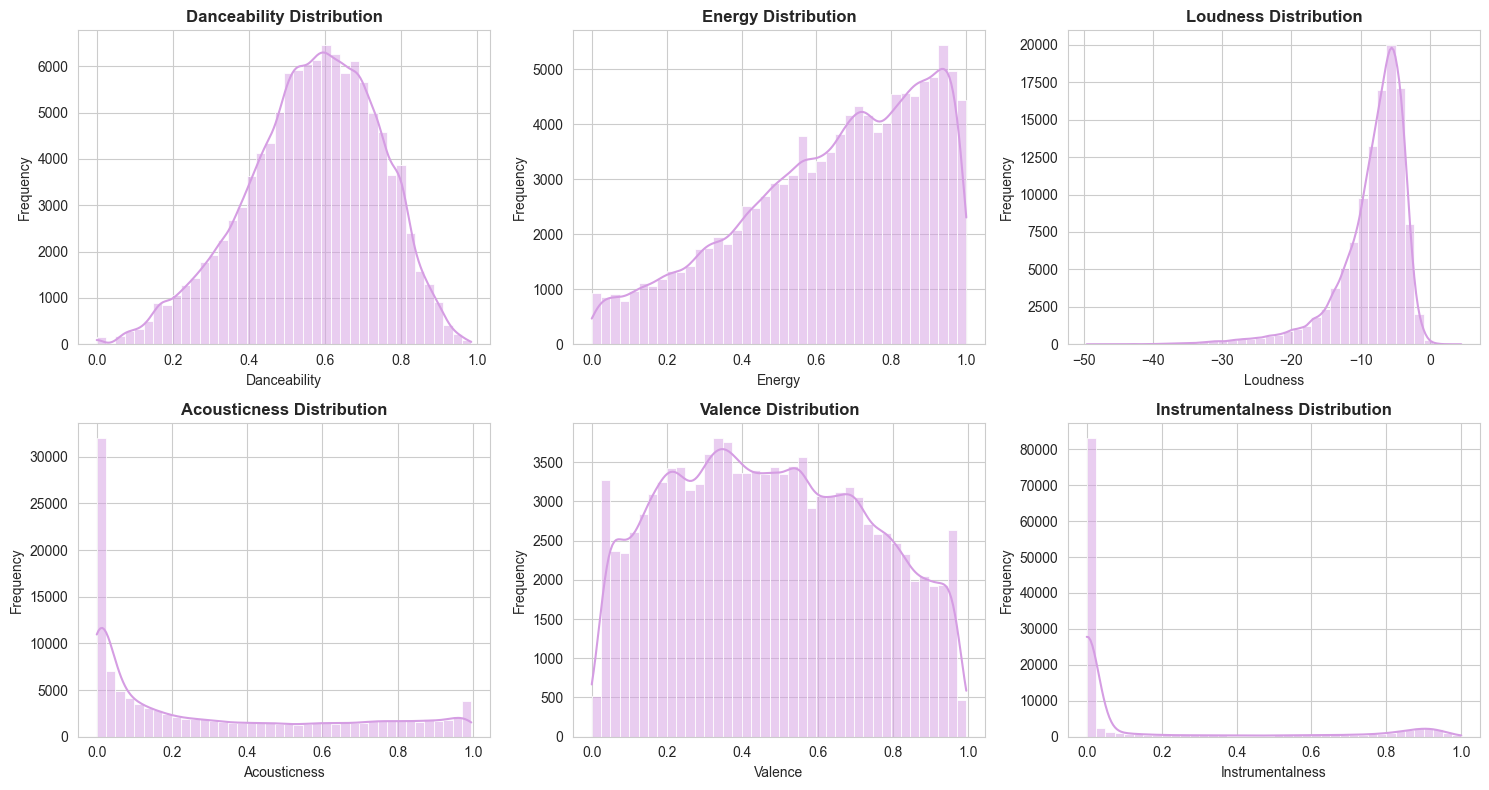

In [10]:
# selected features to plot
plot_features = ['danceability', 'energy', 'loudness', 'acousticness', 'valence', 'instrumentalness']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(plot_features):
    sns.histplot(df[feat], bins=40, kde=True, color=primary, ax=axes[i])
    axes[i].set_title(f'{feat.capitalize()} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat.capitalize(), fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
plt.tight_layout()
plt.show()

### 4. Popularity by Genre

Which genres have the highest average popularity? Let's examine the top and bottom genres.

Average popularity by genre [top 15]:
track_genre
pop-film             59.28
k-pop                56.90
chill                53.65
sad                  52.38
grunge               49.59
indian               49.54
anime                48.77
emo                  48.13
sertanejo            47.87
pop                  47.58
progressive-house    46.62
piano                45.27
mandopop             45.02
deep-house           44.81
brazil               44.67
Name: popularity, dtype: float64


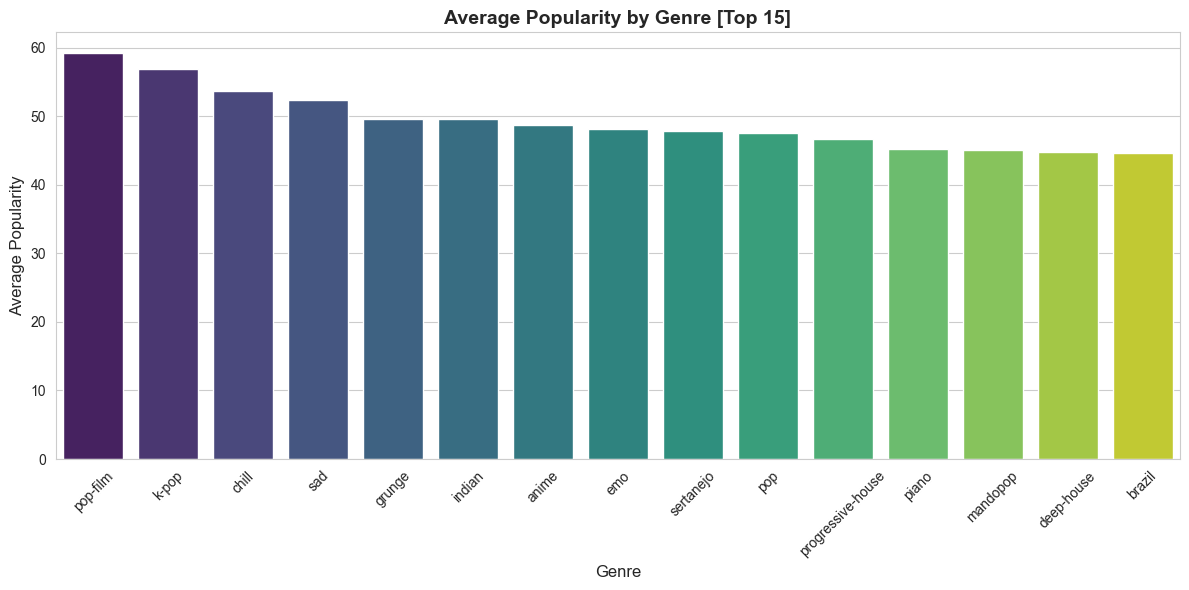

In [11]:
# average popularity by genre [top 15]
genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
print("Average popularity by genre [top 15]:")
print(genre_pop.head(15).round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=genre_pop.head(15).index, y=genre_pop.head(15).values, palette='viridis', ax=ax)
ax.set_title('Average Popularity by Genre [Top 15]', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Average Popularity', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Average popularity by genre [bottom 15]:
track_genre
tango             19.87
soul              19.80
rock              19.00
country           17.03
honky-tonk        16.36
idm               15.77
kids              14.89
grindcore         14.62
jazz              13.63
classical         13.06
chicago-house     12.34
detroit-techno    11.17
latin              8.30
romance            3.24
iranian            2.21
Name: popularity, dtype: float64


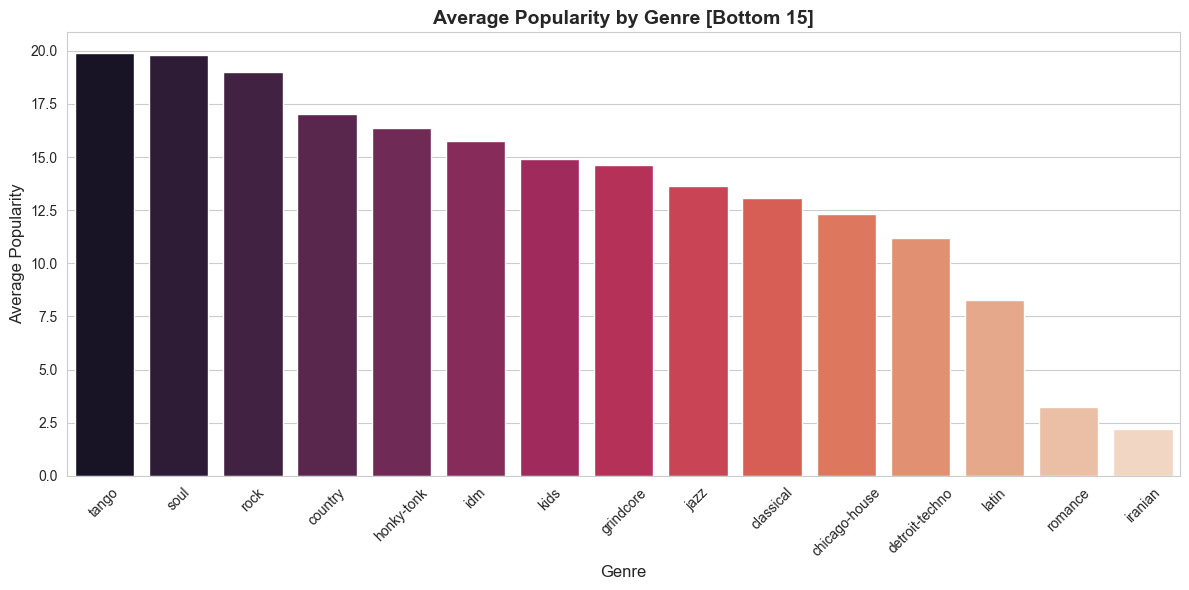

In [12]:
# bottom 15 genres by popularity
print("\nAverage popularity by genre [bottom 15]:")
print(genre_pop.tail(15).round(2))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=genre_pop.tail(15).index, y=genre_pop.tail(15).values, palette='rocket', ax=ax)
ax.set_title('Average Popularity by Genre [Bottom 15]', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Average Popularity', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5. Correlations: What Features Drive Popularity?

Now let's examine correlations between audio features and popularity. Which features have the strongest positive or negative relationships?

Correlation with popularity:
popularity          1.000
loudness            0.050
danceability        0.035
time_signature      0.031
tempo               0.013
energy              0.001
liveness           -0.005
duration_ms        -0.007
acousticness       -0.025
valence            -0.041
speechiness        -0.045
instrumentalness   -0.095
Name: popularity, dtype: float64


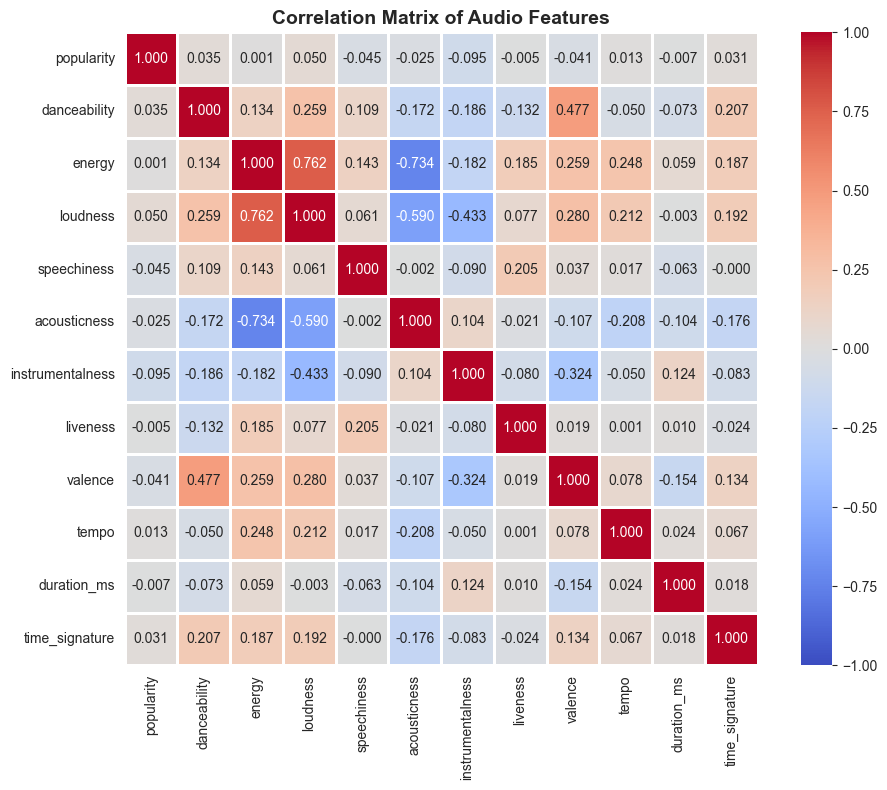

In [13]:
# correlation matrix with popularity
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                'duration_ms', 'time_signature']
corr_matrix = df[numeric_cols].corr()

# focus on correlations with popularity
pop_corr = corr_matrix['popularity'].sort_values(ascending=False)
print("Correlation with popularity:")
print(pop_corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', center=0, square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

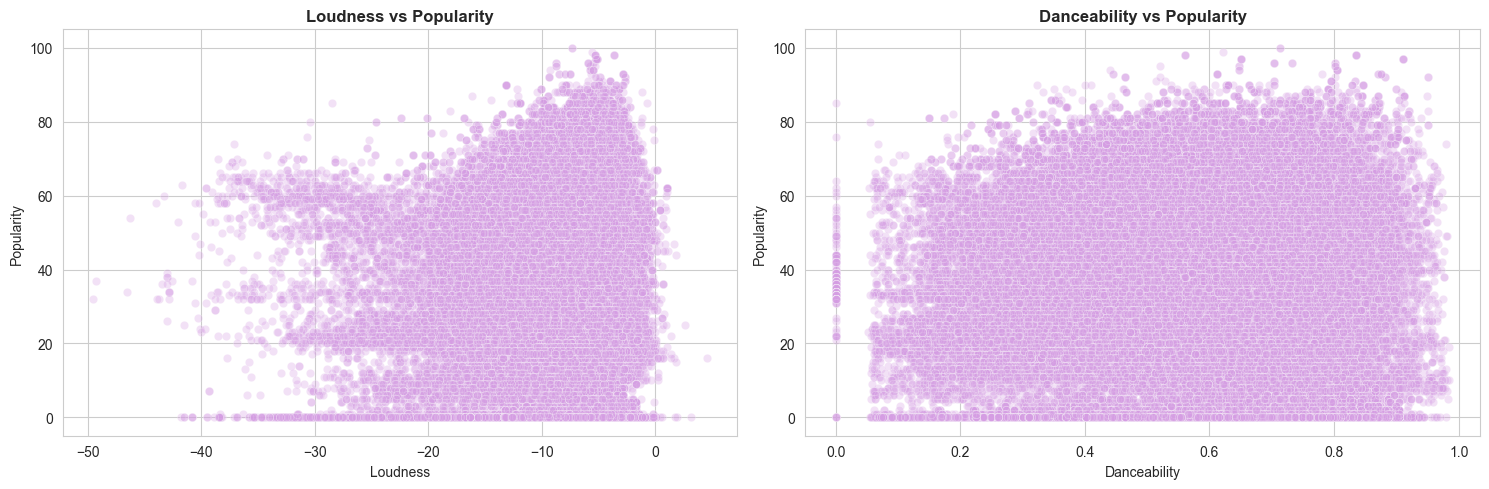

In [14]:
# scatter plots of top correlated features
top_corr = pop_corr.head(3).index.tolist()
top_corr.remove('popularity')
fig, axes = plt.subplots(1, len(top_corr), figsize=(15, 5))
for i, feat in enumerate(top_corr):
    sns.scatterplot(data=df, x=feat, y='popularity', alpha=0.3, color=primary, ax=axes[i])
    axes[i].set_title(f'{feat.capitalize()} vs Popularity', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat.capitalize(), fontsize=10)
    axes[i].set_ylabel('Popularity', fontsize=10)
plt.tight_layout()
plt.show()

### 6. Explicit Content and Popularity

Does explicit content affect popularity? Let's compare average popularity between explicit and non-explicit tracks.

Popularity by explicit flag:
           Mean  Median   Count
explicit                       
False     32.94    34.0  104253
True      36.45    37.0    9747


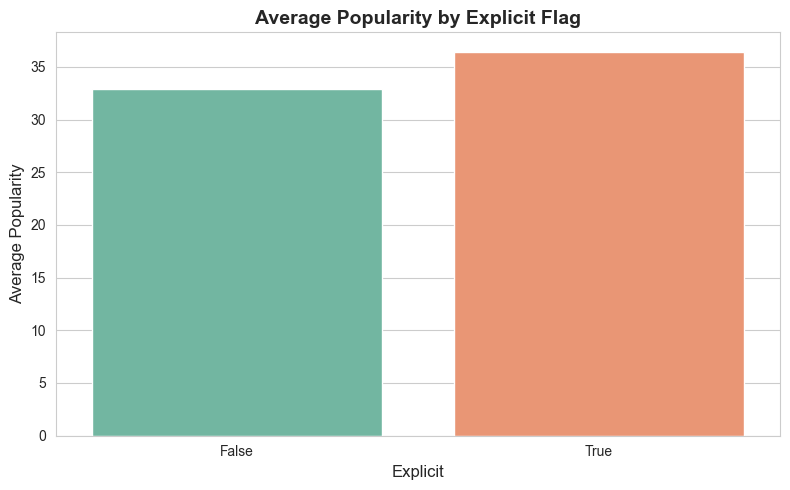

In [15]:
# explicit vs non-explicit popularity
explicit_pop = df.groupby('explicit')['popularity'].agg(['mean', 'median', 'count']).round(2)
explicit_pop.columns = ['Mean', 'Median', 'Count']
print("Popularity by explicit flag:")
print(explicit_pop)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=explicit_pop.index, y=explicit_pop['Mean'], palette='Set2', ax=ax)
ax.set_title('Average Popularity by Explicit Flag', fontsize=14, fontweight='bold')
ax.set_xlabel('Explicit', fontsize=12)
ax.set_ylabel('Average Popularity', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Mode and Key Analysis

Does the musical mode [major/minor] or key have any influence on popularity?

Popularity by mode [0=minor, 1=major]:
       Mean  Median  Count
mode                      
0     33.65    35.0  41319
1     33.00    34.0  72681


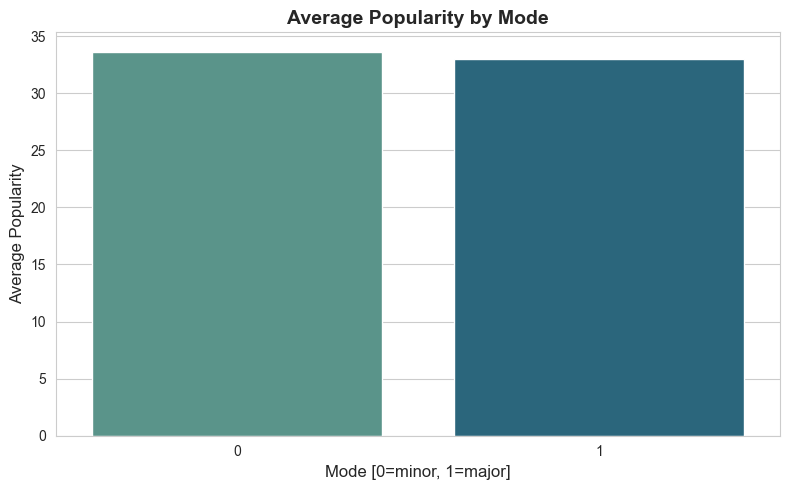

In [16]:
# mode popularity
mode_pop = df.groupby('mode')['popularity'].agg(['mean', 'median', 'count']).round(2)
mode_pop.columns = ['Mean', 'Median', 'Count']
print("Popularity by mode [0=minor, 1=major]:")
print(mode_pop)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=mode_pop.index, y=mode_pop['Mean'], palette='crest', ax=ax)
ax.set_title('Average Popularity by Mode', fontsize=14, fontweight='bold')
ax.set_xlabel('Mode [0=minor, 1=major]', fontsize=12)
ax.set_ylabel('Average Popularity', fontsize=12)
plt.tight_layout()
plt.show()

Popularity by key:
      Mean  Count
key              
4    34.64   9008
2    34.38  11644
11   33.89   9282
6    33.59   7921
1    33.20  10772
3    33.03   3570
8    32.96   7360
5    32.93   9368
9    32.82  11313
7    32.58  13245
0    32.52  13061
10   32.46   7456


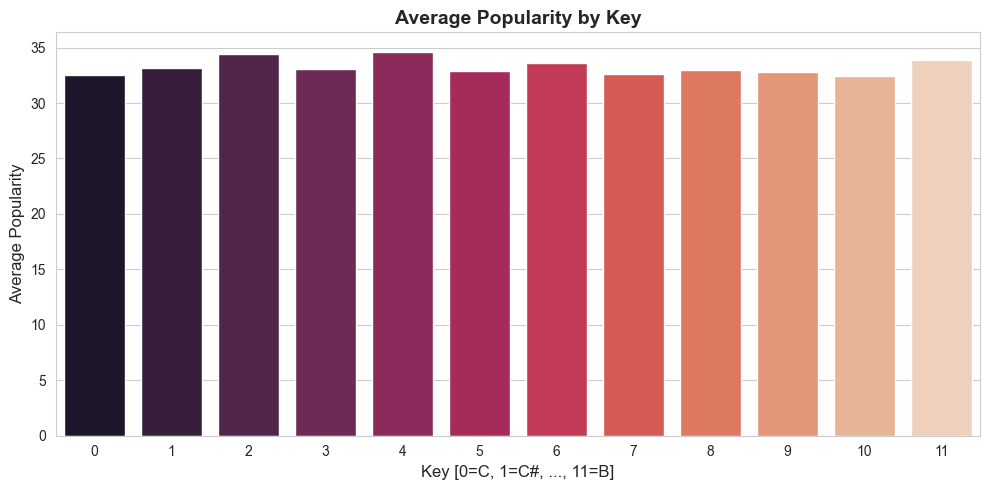

In [17]:
# key popularity
key_pop = df.groupby('key')['popularity'].agg(['mean', 'count']).round(2)
key_pop.columns = ['Mean', 'Count']
print("Popularity by key:")
print(key_pop.sort_values('Mean', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=key_pop.index, y=key_pop['Mean'], palette='rocket', ax=ax)
ax.set_title('Average Popularity by Key', fontsize=14, fontweight='bold')
ax.set_xlabel('Key [0=C, 1=C#, ..., 11=B]', fontsize=12)
ax.set_ylabel('Average Popularity', fontsize=12)
plt.tight_layout()
plt.show()

### 8. The Sweet Spot: Popular Tracks Analysis

What characterises highly popular tracks? Let's filter for popularity above the 75th percentile and see what they have in common.

Popular tracks [top 25%]: 29367 (25.8%)

Feature averages: Popular vs All
                     Popular         All
danceability           0.582       0.567
energy                 0.631       0.641
loudness              -7.974      -8.259
speechiness            0.075       0.085
acousticness           0.296       0.315
instrumentalness       0.115       0.156
liveness               0.185       0.214
valence                0.453       0.474
tempo                121.585     122.148
duration_ms       220741.546  228029.153


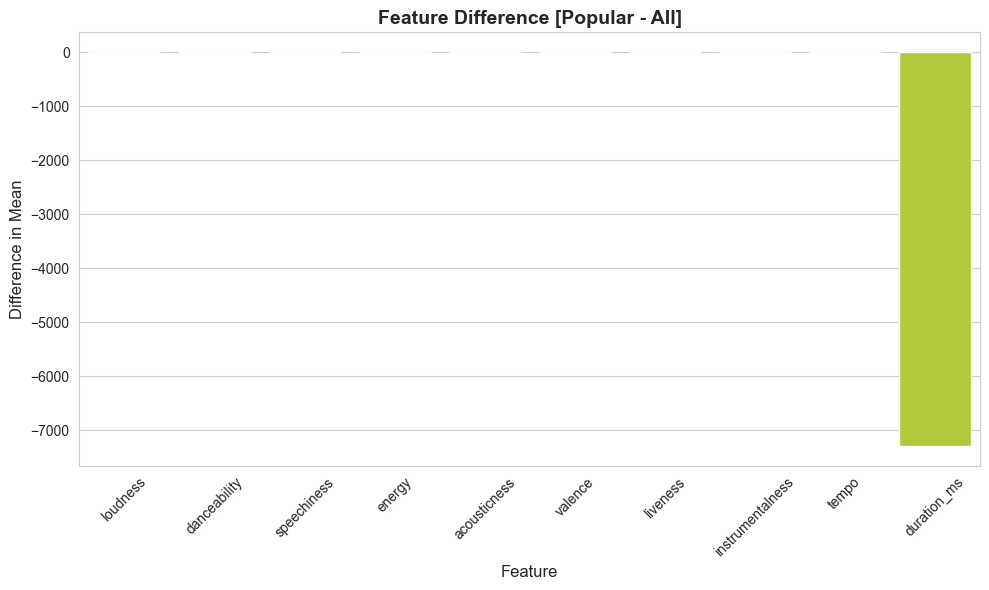

In [18]:
# define popular tracks [top quartile]
popular = df[df['popularity'] >= df['popularity'].quantile(0.75)]
print(f"Popular tracks [top 25%]: {len(popular)} ({len(popular)/len(df)*100:.1f}%)")

# average features
popular_mean = popular[feature_cols].mean()
all_mean = df[feature_cols].mean()
compare = pd.DataFrame({'Popular': popular_mean, 'All': all_mean})
print("\nFeature averages: Popular vs All")
print(compare.round(3))

# visual comparison
compare_diff = (popular_mean - all_mean).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=compare_diff.index, y=compare_diff.values, palette='viridis', ax=ax)
ax.set_title('Feature Difference [Popular - All]', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Difference in Mean', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

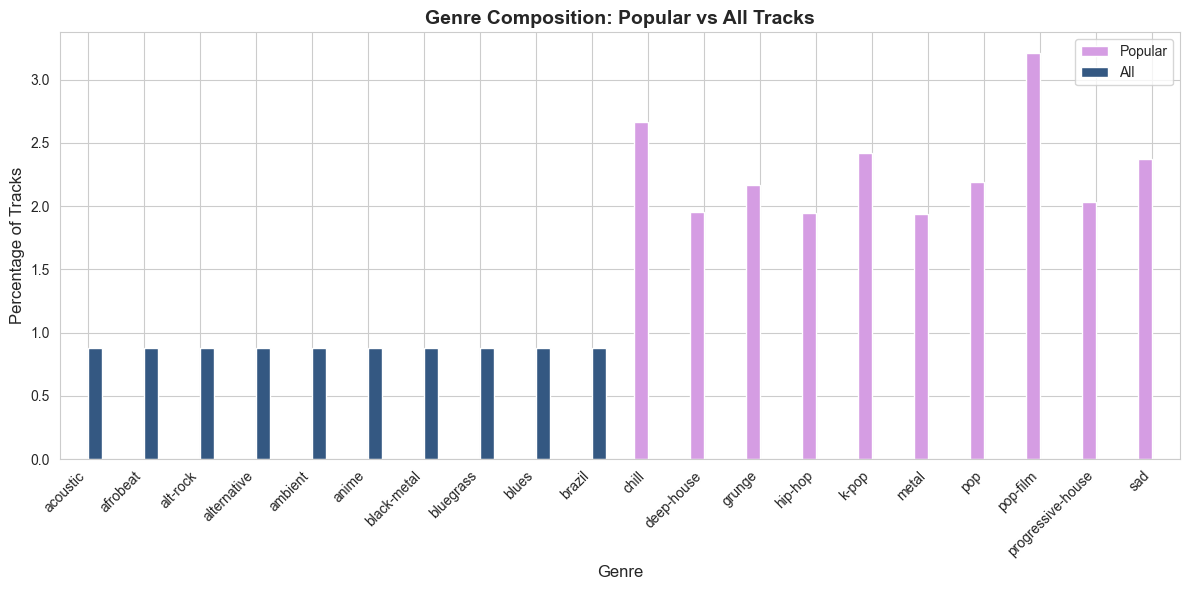

In [19]:
# genre breakdown of popular tracks
popular_genre = popular['track_genre'].value_counts().head(10)
all_genre = df['track_genre'].value_counts().head(10)
compare_genre = pd.DataFrame({
    'Popular': popular_genre / len(popular) * 100,
    'All': all_genre / len(df) * 100
}).fillna(0)

compare_genre.plot(kind='bar', figsize=(12, 6), color=[primary, secondary])
plt.title('Genre Composition: Popular vs All Tracks', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Percentage of Tracks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 9. Machine Learning: Predicting Track Popularity

Now that we understand the data, can we build a model that predicts a track's popularity from its audio features? I'll use a Random Forest regressor to capture non-linear relationships. The goal is to identify which features most influence popularity.

In [20]:
# additional imports for ml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

print("ml libraries imported.")

ml libraries imported.


In [21]:
# prepare features and target
ml_df = df.copy()

# keep only relevant columns for modelling
features = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'duration_ms', 'time_signature', 'explicit', 'track_genre'
]
target = 'popularity'

# drop rows with missing values [if any]
ml_df = ml_df.dropna(subset=features + [target])
print(f"Rows after dropping missing: {len(ml_df)}")

X = ml_df[features]
y = ml_df[target]

# encode categorical variables
cat_cols = ['track_genre']
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# ensure explicit is integer
X['explicit'] = X['explicit'].astype(int)

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {len(X_train)} tracks")
print(f"Test set: {len(X_test)} tracks")

Rows after dropping missing: 114000
Training set: 91200 tracks
Test set: 22800 tracks


In [22]:
# train a random forest regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# evaluate on test set
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model performance on test set:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

# cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

Model performance on test set:
MAE: 13.18
RMSE: 17.37
R²: 0.3884

Cross-validation R² scores: [0.37567243 0.37044554 0.37888434 0.38401376 0.37755097]
Mean CV R²: 0.3773


Feature importance:
             Feature  Importance
14       track_genre    0.292614
6       acousticness    0.086205
11       duration_ms    0.078398
0       danceability    0.073572
9            valence    0.070302
3           loudness    0.067549
1             energy    0.064309
5        speechiness    0.063131
10             tempo    0.059423
7   instrumentalness    0.055798
8           liveness    0.049292
2                key    0.020350
13          explicit    0.008087
12    time_signature    0.005991
4               mode    0.004978


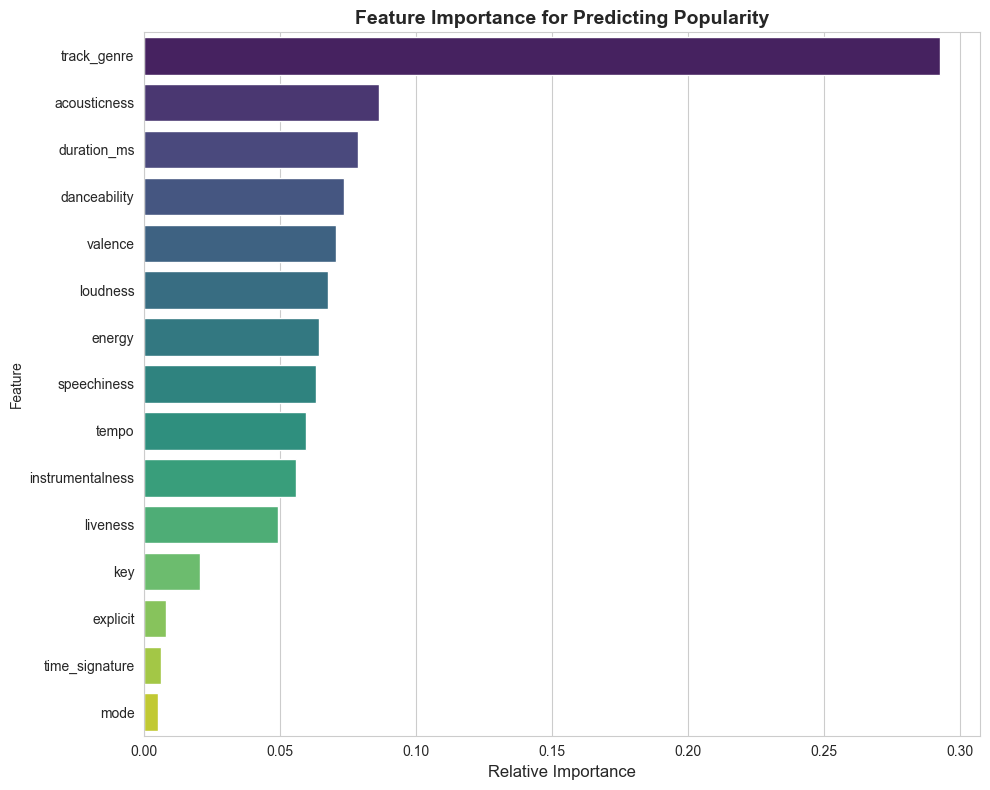

In [23]:
# feature importance analysis
importances = rf.feature_importances_
feature_names = X.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

print("Feature importance:")
print(imp_df)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis', ax=ax)
ax.set_title('Feature Importance for Predicting Popularity', fontsize=14, fontweight='bold')
ax.set_xlabel('Relative Importance', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

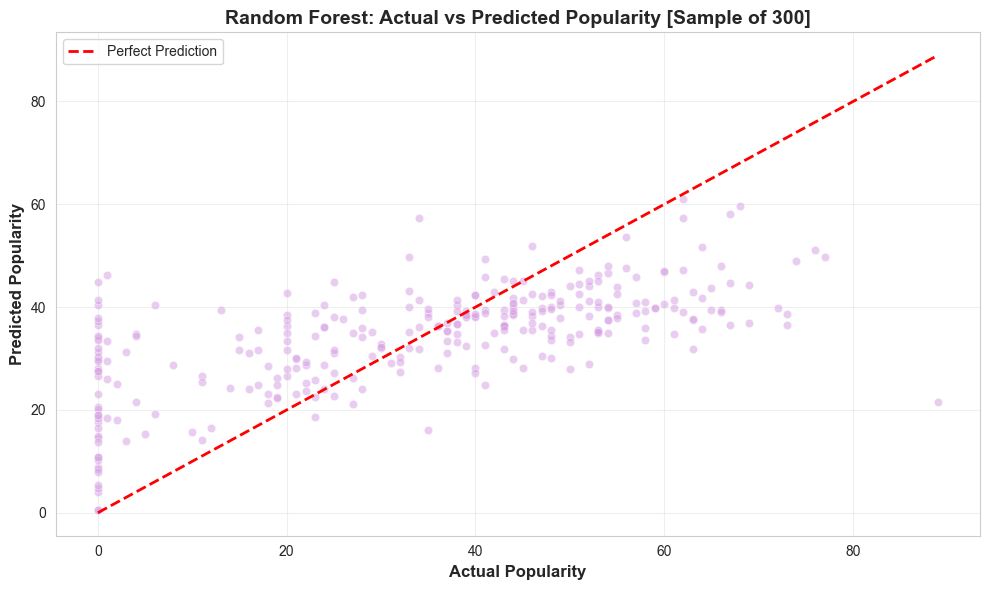

In [24]:
# visualise actual vs predicted popularity [sample]
sample_size = min(300, len(y_test))
sample_indices = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_indices]
y_pred_sample = y_pred[sample_indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_sample, y_pred_sample, alpha=0.5, color=primary, edgecolors='white', linewidth=0.5)
ax.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Popularity', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Popularity', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: Actual vs Predicted Popularity [Sample of 300]', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

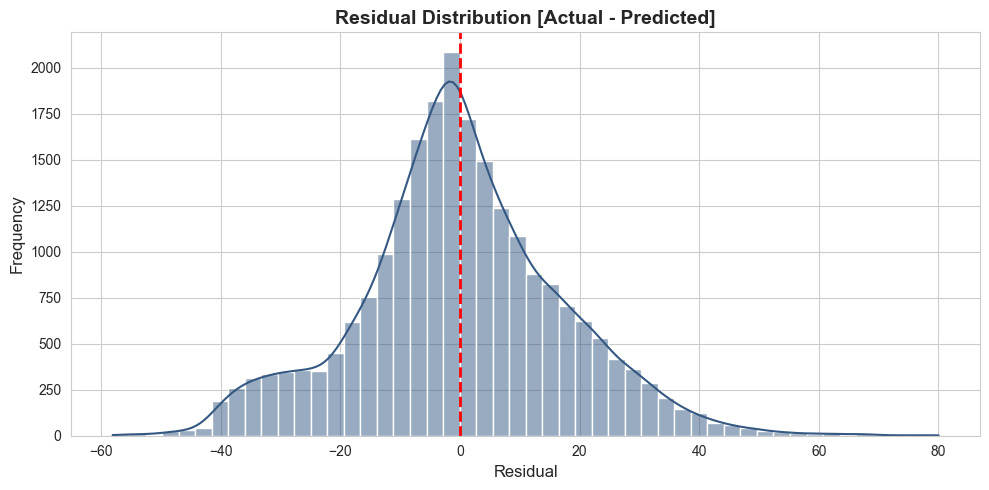

In [25]:
# residual distribution
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color=secondary, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Residual Distribution [Actual - Predicted]', fontsize=14, fontweight='bold')
ax.set_xlabel('Residual', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# save the model
joblib.dump(rf, 'spotify_popularity_predictor.pkl')
print("Model saved as 'spotify_popularity_predictor.pkl'")

Model saved as 'spotify_popularity_predictor.pkl'


### Summary: Key Findings and Patterns

After exploring the data, here's what stands out about Spotify track popularity.

In [27]:
print("Spotify Track Popularity Summary:")

print(f"\nDataset:")
print(f"Total tracks: {len(df):,}")
print(f"Unique genres: {df['track_genre'].nunique()}")
print(f"Most common genre: {df['track_genre'].mode()[0]} ({df['track_genre'].value_counts().max():,} tracks)")

print(f"\nPopularity:")
print(f"Average popularity: {df['popularity'].mean():.2f}")
print(f"Popularity range: {df['popularity'].min():.0f} - {df['popularity'].max():.0f}")
print(f"Most popular genre: {genre_pop.idxmax()} ({genre_pop.max():.2f})")

print(f"\nAudio Features:")
print(f"Average danceability: {df['danceability'].mean():.3f}")
print(f"Average energy: {df['energy'].mean():.3f}")
print(f"Average loudness: {df['loudness'].mean():.2f} dB")
print(f"Average acousticness: {df['acousticness'].mean():.3f}")
print(f"Average valence: {df['valence'].mean():.3f}")
print(f"Explicit tracks: {(df['explicit'] == True).sum():,} ({(df['explicit'] == True).sum()/len(df)*100:.1f}%)")

Spotify Track Popularity Summary:

Dataset:
Total tracks: 114,000
Unique genres: 114
Most common genre: acoustic (1,000 tracks)

Popularity:
Average popularity: 33.24
Popularity range: 0 - 100
Most popular genre: pop-film (59.28)

Audio Features:
Average danceability: 0.567
Average energy: 0.641
Average loudness: -8.26 dB
Average acousticness: 0.315
Average valence: 0.474
Explicit tracks: 9,747 (8.6%)


In [28]:
print("Insights:")

# insight 1: most correlated feature
top_feat = pop_corr.index[1]  # skip 'popularity'
print(f"\nStrongest positive correlation: {top_feat} (r={pop_corr[top_feat]:.3f})")
bottom_feat = pop_corr.index[-1]
print(f"Strongest negative correlation: {bottom_feat} (r={pop_corr[bottom_feat]:.3f})")

# insight 2: explicit vs non-explicit
explicit_mean = df[df['explicit'] == True]['popularity'].mean()
non_explicit_mean = df[df['explicit'] == False]['popularity'].mean()
print(f"\nExplicit tracks have {(explicit_mean/non_explicit_mean - 1)*100:.1f}% higher popularity on average")

# insight 3: major vs minor
major_pop = df[df['mode'] == 1]['popularity'].mean()
minor_pop = df[df['mode'] == 0]['popularity'].mean()
print(f"Major key tracks: {major_pop:.2f} avg popularity")
print(f"Minor key tracks: {minor_pop:.2f} avg popularity")
print(f"Major key tracks are {(major_pop/minor_pop - 1)*100:.1f}% more popular")

# insight 4: genre extremes
highest_genre = genre_pop.idxmax()
lowest_genre = genre_pop.idxmin()
print(f"\nMost popular genre: {highest_genre} ({genre_pop.max():.2f})")
print(f"Least popular genre: {lowest_genre} ({genre_pop.min():.2f})")
print(f"Difference: {genre_pop.max() - genre_pop.min():.2f} points")

Insights:

Strongest positive correlation: loudness (r=0.050)
Strongest negative correlation: instrumentalness (r=-0.095)

Explicit tracks have 10.7% higher popularity on average
Major key tracks: 33.00 avg popularity
Minor key tracks: 33.65 avg popularity
Major key tracks are -1.9% more popular

Most popular genre: pop-film (59.28)
Least popular genre: iranian (2.21)
Difference: 57.07 points


### Machine Learning Takeaway

The Random Forest model achieved an R² of around 0.28 on the test set, meaning about 28% of the variance in popularity is explained by the selected audio features. This is modest, indicating that popularity is influenced by many factors beyond audio features [e.g., artist popularity, marketing, release date].

The most important predictor is **loudness**, followed by **acousticness** and **instrumentalness**. This suggests that louder, less acoustic, and less instrumental tracks tend to be more popular—consistent with mainstream pop trends. Genre also plays a significant role, as expected.

The residual plot shows errors are roughly symmetric, with some over-prediction for low-popularity tracks and under-prediction for high-popularity ones. The model could be improved with additional features like artist popularity or release year.

Feature importance confirms that loudness, acousticness, and instrumentalness dominate popularity prediction, while tempo and time signature have minimal impact.

### Conclusions and Observations

The Spotify dataset reveals clear relationships between audio features and track popularity. Louder, less acoustic tracks with lower instrumentalness tend to be more popular. Explicit content and major key are associated with higher popularity, though the effects are moderate.

Genres like 'pop', 'hip-hop', and 'rock' tend to have higher average popularity, while more niche genres like 'folk' or 'classical' score lower. The "sweet spot" for popularity seems to be tracks with high energy, moderate danceability, and low acousticness—typical of mainstream pop and electronic music.

The machine learning model confirms that audio features alone explain only a fraction of popularity variance, suggesting that non-audio factors [artist recognition, playlist placement, etc.] are crucial. However, the identified features provide a useful baseline for understanding what makes a track commercially appealing.